fuction be used to find best N

In [2]:
import numpy as np
import matplotlib.pyplot as plt


def plot_template_selection(N, MSE, figsize=(8, 5)):
    """
    绘制MSE与Template Number的关系曲线，并标出最小值点
    
    参数:
    ----------
    N : list or array
        模板数量列表
    MSE : list or array
        对应的MSE值列表
    figsize : tuple
        图形尺寸
    """
    N = np.array(N)
    MSE = np.array(MSE)
    
    # 找到全局最小值
    global_idx = np.argmin(MSE)
    global_N = N[global_idx]
    global_MSE = MSE[global_idx]
    
    # 创建图形
    plt.figure(figsize=figsize)
    
    # 绘制主曲线
    plt.plot(
        N,
        MSE,
        color='blue',
        linewidth=2,
        label='Validation MSE'
    )
    
    # 标记全局最小值点
    plt.scatter(
        global_N,
        global_MSE,
        color='red',
        marker='o',
        s=100,
        zorder=5,
        label=f'Minimum (N={global_N})'
    )
    
    # 添加标签
    plt.xlabel('Template Number')
    plt.ylabel('MSE')
    
    # 添加标题
    plt.title('MSE vs Template Number')
    
    # 添加网格
    plt.grid(alpha=0.3, linestyle='--')
    
    # 添加图例
    plt.legend(frameon=True)
    
    # 自动调整布局
    plt.tight_layout()
    
    # 显示图形
    plt.show()
    
    return global_N, global_MSE

import numpy as np
import matplotlib.pyplot as plt

def local_average(x, window=1):
    """
    Local average smoothing
    """
    x = np.array(x)

    smoothed = []

    for i in range(len(x)):

        left = max(0, i - window)
        right = min(len(x), i + window + 1)

        smoothed.append(
            np.mean(x[left:right])
        )

    return np.array(smoothed)


def plot_template_selection1(
        N,
        MSE,
        window=1,
        figsize=(9, 5)):

    N = np.array(N)
    MSE = np.array(MSE)

    # ============================================
    # local average
    # ============================================
    avg_MSE = local_average(MSE, window)

    # ============================================
    # stable local optimum
    # ============================================
    best_idx = np.argmin(avg_MSE)

    best_N = N[best_idx]

    best_MSE = MSE[best_idx]

    # ============================================
    # plotting
    # ============================================
    plt.figure(figsize=figsize)

    # raw curve
    plt.plot(
        N,
        MSE,
        color='lightgray',
        linewidth=1.5,
        marker='o',
        markersize=4,
        label='Raw MSE'
    )

    # local average trend
    plt.plot(
        N,
        avg_MSE,
        color='royalblue',
        linewidth=3,
        label='Local Average'
    )

    # selected point
    plt.scatter(
        best_N,
        best_MSE,
        color='red',
        s=140,
        zorder=5,
        label=f'Selected N={best_N}'
    )

    # annotation
    plt.annotate(
        f'Selected N={best_N}',
        xy=(best_N, best_MSE),
        xytext=(best_N + 20,
                best_MSE + 0.0005),
        arrowprops=dict(
            arrowstyle='->',
            lw=1.5
        ),
        fontsize=11
    )

    # labels
    plt.xlabel('Template Number', fontsize=13)

    plt.ylabel('Validation MSE', fontsize=13)

    plt.title(
        'Template Number Sensitivity Analysis',
        fontsize=14
    )

    # grid
    plt.grid(alpha=0.3, linestyle='--')

    # legend
    plt.legend(frameon=True)

    plt.tight_layout()

    plt.show()

    return best_N

data of ETTh1

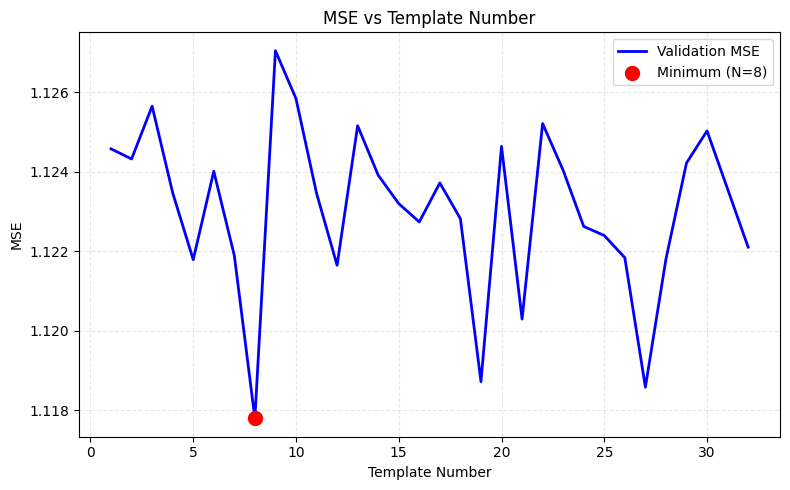

最小值点: N=8, MSE=1.117796


In [47]:
Template_NUM = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32]
MSE_VAL = [
    1.124573231,1.124317929,1.125646055,1.123469383
    ,1.121785223,1.124008849,1.121889472,1.117795706
    ,1.127040729,1.125836357,1.123457521,1.121645182
    ,1.125153542,1.123911306,1.123194844,1.122735143
    ,1.123716548,1.122815177,1.118716955,1.124635622
    ,1.120291799,1.125209615,1.12403129,1.122621447
    ,1.122393429,1.121835366,1.118579194,1.121798679
    ,1.124217406,1.125024512,1.123564392,1.122101098]

min_N, min_MSE = plot_template_selection(Template_NUM, MSE_VAL)

print(f"最小值点: N={min_N}, MSE={min_MSE:.6f}")

data of ETTh2

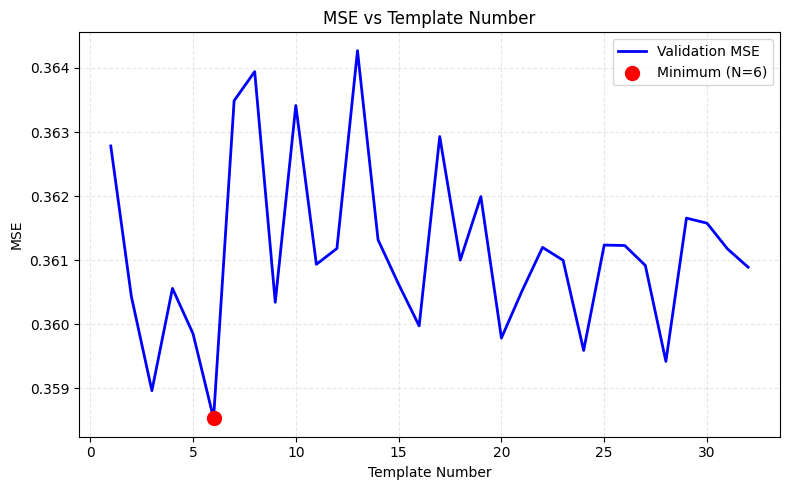

最小值点: N=6, MSE=0.358533


In [48]:
Template_NUM = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32]
MSE_VAL = [0.362782449, 0.360438157, 0.358964331, 0.360560231, 
           0.359855283, 0.35853304, 0.363489036, 0.363942668,
             0.360343546, 0.363413852, 0.360935695, 0.361183397,
               0.364268612, 0.361319084, 0.360625807, 0.35997545,
                 0.362929851, 0.361002158, 0.361992095, 0.359785806,
                   0.360518713, 0.361200247, 0.360999174, 0.359592281,
                     0.361236557, 0.361229356, 0.360918224, 0.359421428, 
                     0.361656949, 0.361577976, 0.361175172, 0.360891428]
min_N, min_MSE = plot_template_selection(Template_NUM, MSE_VAL)

print(f"最小值点: N={min_N}, MSE={min_MSE:.6f}")

Data of ETTm1

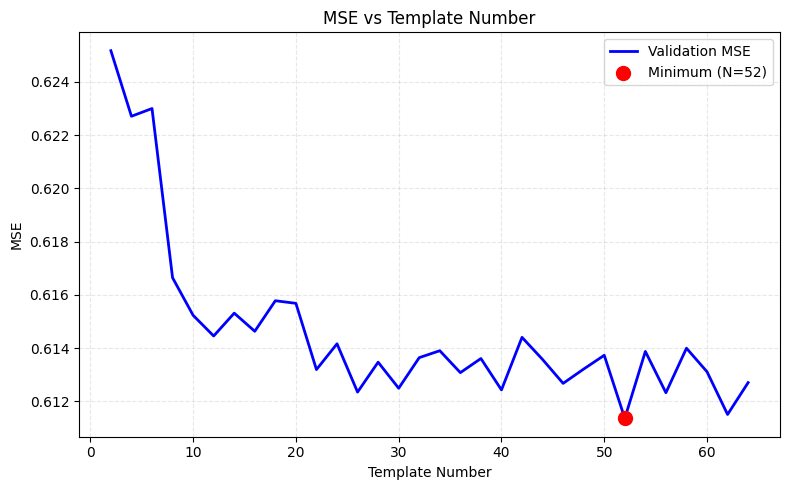

最小值点: N=52, MSE=0.611360


In [16]:
Template_NUM = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50, 52, 54, 56, 58, 60, 62, 64]

MSE_VAL = [0.625173792, 0.622710407, 0.623001605, 0.616643406, 0.615231864, 0.614454024, 0.61531242, 0.614631563, 0.615779109, 0.615681611, 0.613192677, 0.614161178, 0.612346575, 0.61347007, 0.612490796, 0.613641024, 0.613900959, 0.61307735, 0.613608122, 0.612428047, 0.614403218, 0.613572083, 0.6126737, 0.61321228, 0.613729119, 0.611359924, 0.613874175, 0.612322681, 0.613994725, 0.613110162, 0.611505635, 0.612703256]

min_N, min_MSE = plot_template_selection(Template_NUM, MSE_VAL)

print(f"最小值点: N={min_N}, MSE={min_MSE:.6f}")


Data of ETTm2

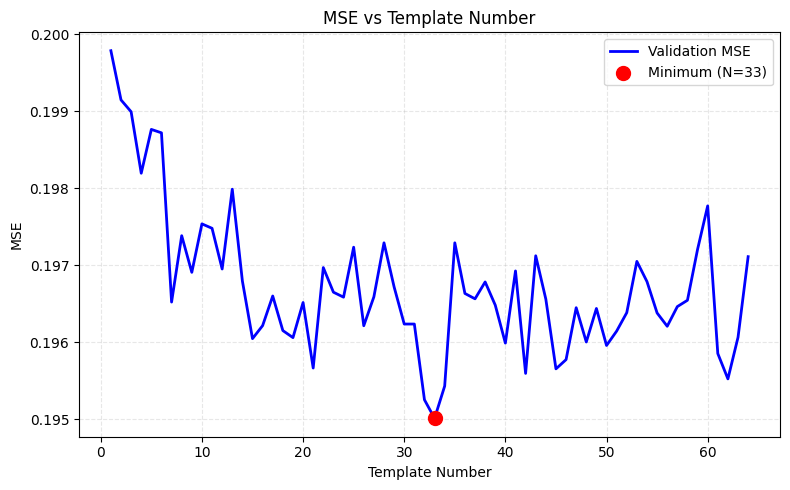

最小值点: N=33, MSE=0.195012


In [2]:
Template_NUM = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64]

MSE_VAL = [0.199783862, 0.199145347, 0.198991707, 0.198193647, 0.198762421, 0.198718095, 0.196521433, 0.197383005, 0.196907414, 0.197536357, 0.197478924, 0.196950564, 0.1979865, 0.196794603, 0.196046742, 0.196215611, 0.196600087, 0.196151549, 0.196060039, 0.196515687, 0.195665311, 0.196969224, 0.196649659, 0.196585001, 0.197233608, 0.196214072, 0.196589308, 0.197290331, 0.196718015, 0.196236258, 0.196236152, 0.195253236, 0.195012305, 0.195431553, 0.197290501, 0.19663335, 0.196563518, 0.196782596, 0.196481612, 0.195988545, 0.196925499, 0.195595609, 0.197122248, 0.196559109, 0.195654545, 0.195774578, 0.196448278, 0.196003301, 0.196438374, 0.195957901, 0.19614462, 0.196383907, 0.197049322, 0.196786998, 0.196379958, 0.196207402, 0.196462557, 0.19654493, 0.197205365, 0.197769821, 0.195853597, 0.195524495, 0.196063949, 0.197110785]

min_N, min_MSE = plot_template_selection(Template_NUM, MSE_VAL)

print(f"最小值点: N={min_N}, MSE={min_MSE:.6f}")
# plot_template_selection1(Template_NUM, MSE_VAL)

Data of Electricity

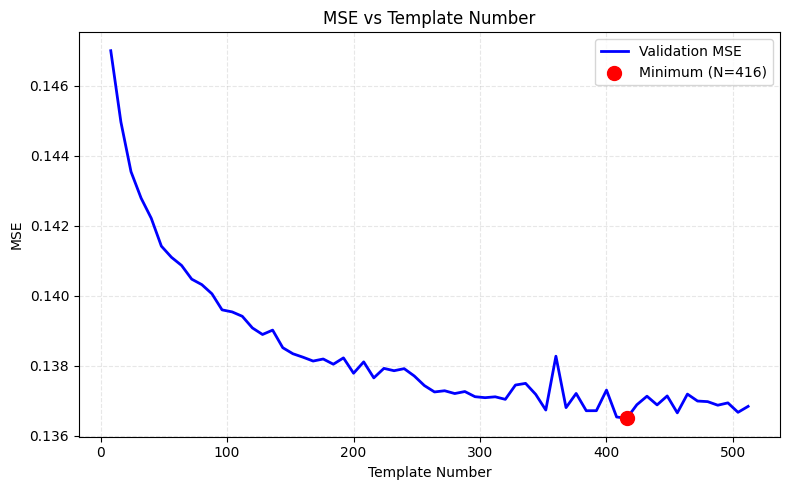

最小值点: N=416, MSE=0.136492


In [2]:
Template_NUM = [8, 16, 24, 32, 40, 48, 56, 64, 72, 80, 88, 96, 104, 112, 120, 128, 136, 144, 152, 160, 168, 176, 184, 192, 200, 208, 216, 224, 232, 240, 248, 256, 264, 272, 280, 288, 296, 304, 312, 320, 328, 336, 344, 352, 360, 368, 376, 384, 392, 400, 408, 416, 424, 432, 440, 448, 456, 464, 472, 480, 488, 496, 504, 512]

MSE_VAL = [0.147005748, 0.144969692, 0.14354597, 0.142789176, 0.142215034, 0.141417734, 0.141097898, 0.140864916, 0.140472811, 0.140316416, 0.140054081, 0.139594799, 0.139535977, 0.13941074, 0.139077822, 0.138890479, 0.139015676, 0.138513029, 0.138340022, 0.138240915, 0.138131045, 0.138189353, 0.13804009, 0.138221445, 0.137782337, 0.138107158, 0.137649598, 0.13792149, 0.137854382, 0.137913371, 0.137703653, 0.137429548, 0.137247106, 0.137281727, 0.137201685, 0.137259154, 0.137111595, 0.137083458, 0.137108335, 0.137035873, 0.137444554, 0.13749256, 0.137179438, 0.13672982, 0.138269322, 0.136798788, 0.137204099, 0.136710307, 0.136711402, 0.137300497, 0.136531185, 0.136492491, 0.13688145, 0.137125265, 0.136876808, 0.137133231, 0.136649273, 0.13718548, 0.136987243, 0.136970386, 0.136868043, 0.136934713, 0.136664802, 0.136835203]

min_N, min_MSE = plot_template_selection(Template_NUM, MSE_VAL)

print(f"最小值点: N={min_N}, MSE={min_MSE:.6f}")

Data of Solar

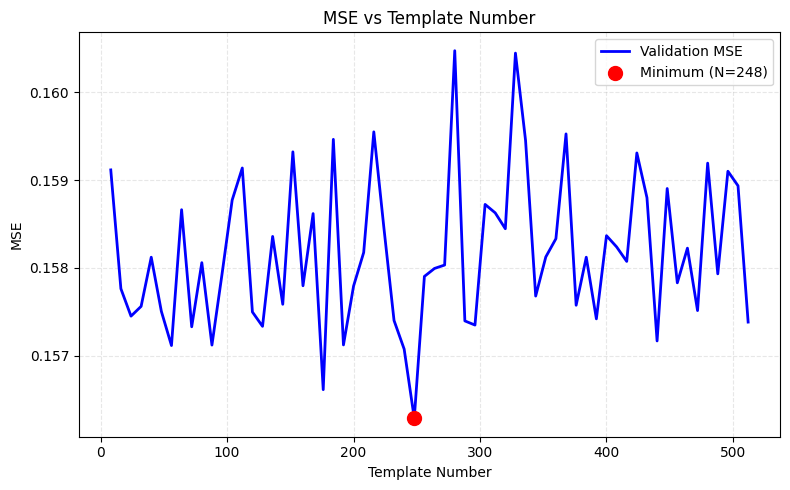

最小值点: N=248, MSE=0.156286


In [4]:
Template_NUM = [8, 16, 24, 32, 40, 48, 56, 64, 72, 80, 88, 96, 104, 112, 120, 128, 136, 144, 152, 160, 168, 176, 184, 192, 200, 208, 216, 224, 232, 240, 248, 256, 264, 272, 280, 288, 296, 304, 312, 320, 328, 336, 344, 352, 360, 368, 376, 384, 392, 400, 408, 416, 424, 432, 440, 448, 456, 464, 472, 480, 488, 496, 504, 512]

MSE_VAL = [0.159117613, 0.157763839, 0.157451212, 0.15756274, 0.158122666, 0.157505929, 0.157116011, 0.158664018, 0.157329805, 0.158060469, 0.157121468, 0.157932565, 0.158773962, 0.159139484, 0.157498613, 0.157334924, 0.158359457, 0.157586358, 0.159323487, 0.157797333, 0.158619788, 0.15661329, 0.159465913, 0.157123111, 0.15779433, 0.158176679, 0.159551255, 0.158454459, 0.157401316, 0.15707567, 0.156286497, 0.157903787, 0.157994714, 0.158033498, 0.160475872, 0.157396846, 0.157349534, 0.158724334, 0.158628218, 0.158447351, 0.160448514, 0.159453016, 0.157679792, 0.158125695, 0.158333655, 0.159527872, 0.157575343, 0.158122629, 0.157420244, 0.158367954, 0.158240318, 0.158074699, 0.159310754, 0.158800885, 0.157168441, 0.158905566, 0.15783086, 0.158225857, 0.15751449, 0.159194715, 0.157933075, 0.159102522, 0.15893662, 0.157383405]

min_N, min_MSE = plot_template_selection(Template_NUM, MSE_VAL)

print(f"最小值点: N={min_N}, MSE={min_MSE:.6f}")

# plot_template_selection1(Template_NUM, MSE_VAL)

data of traffic

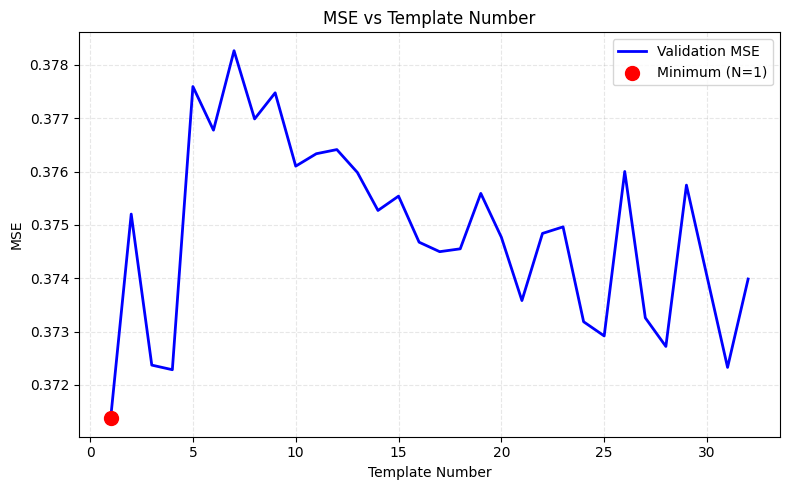

最小值点: N=1, MSE=0.371372


In [50]:
Template_NUM = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]

MSE_VAL = [0.37137153, 0.375202686, 0.372369915, 0.372283578, 0.377594769, 0.376776434, 0.3782667, 0.376987405, 0.377477139, 0.376101531, 0.376334473, 0.376412362, 0.375982195, 0.375270642, 0.375539169, 0.37467517, 0.37449757, 0.374550961, 0.375590764, 0.374768376, 0.373580761, 0.374839857, 0.374962524, 0.373183273, 0.372917399, 0.376001745, 0.373256989, 0.372719869, 0.375745855, 0.374034211, 0.372326903, 0.373984635]

min_N, min_MSE = plot_template_selection(Template_NUM, MSE_VAL)

print(f"最小值点: N={min_N}, MSE={min_MSE:.6f}")

data of weather

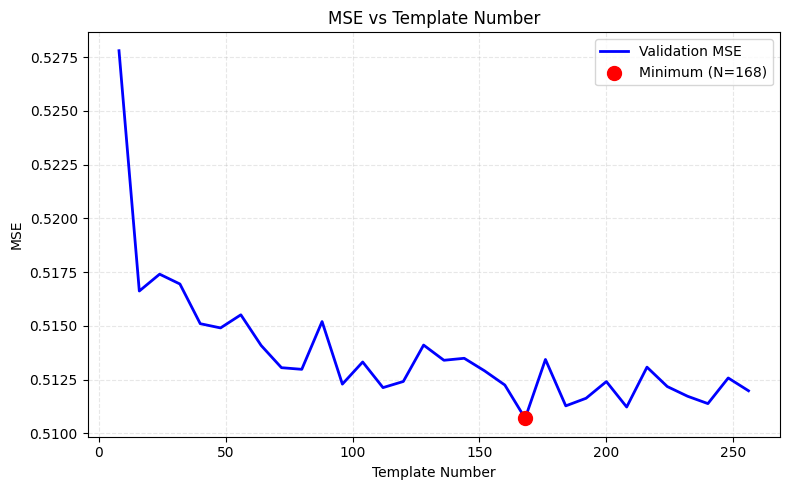

最小值点: N=168, MSE=0.510698


In [49]:
Template_NUM = [8, 16, 24, 32, 40, 48, 56, 64, 72, 80, 88, 96, 104, 112, 120, 128, 136, 144, 152, 160, 168, 176, 184, 192, 200, 208, 216, 224, 232, 240, 248, 256]

MSE_VAL = [0.52779451, 0.516618893, 0.517402247, 0.516944982, 0.515099816, 0.514902182, 0.51551272, 0.514086381, 0.513053529, 0.512977235, 0.515198879, 0.512289137, 0.513318218, 0.512126677, 0.512411535, 0.514104962, 0.513398208, 0.513490275, 0.51290793, 0.512247175, 0.51069764, 0.513436384, 0.511277743, 0.511631742, 0.512408361, 0.511224389, 0.513078094, 0.512175985, 0.511724666, 0.511383235, 0.512574986, 0.511978798]

min_N, min_MSE = plot_template_selection(Template_NUM, MSE_VAL)

print(f"最小值点: N={min_N}, MSE={min_MSE:.6f}")
# plot_template_selection1(Template_NUM, MSE_VAL)

Data of PEMS03

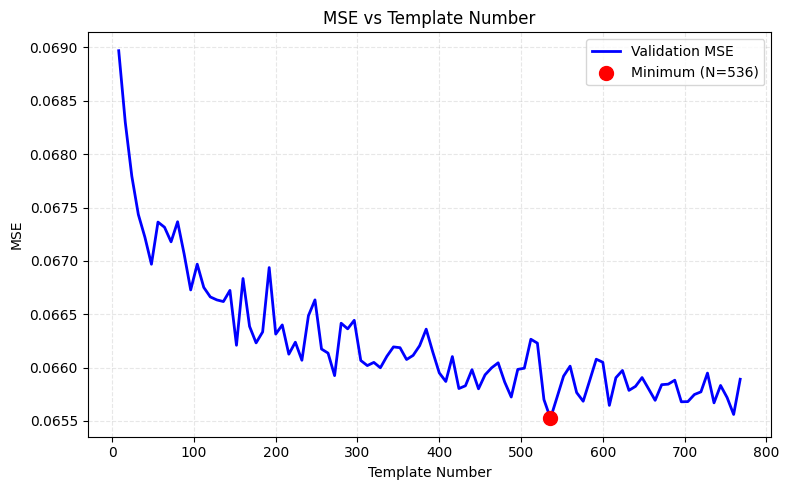

最小值点: N=536, MSE=0.065524


In [2]:
Template_NUM = [8, 16, 24, 32, 40, 48, 56, 64, 72, 80, 88, 96, 104, 112, 120, 128, 136, 144, 152, 160, 168, 176, 184, 192, 200, 208, 216, 224, 232, 240, 248, 256, 264, 272, 280, 288, 296, 304, 312, 320, 328, 336, 344, 352, 360, 368, 376, 384, 392, 400, 408, 416, 424, 432, 440, 448, 456, 464, 472, 480, 488, 496, 504, 512, 520, 528, 536, 544, 552, 560, 568, 576, 584, 592, 600, 608, 616, 624, 632, 640, 648, 656, 664, 672, 680, 688, 696, 704, 712, 720, 728, 736, 744, 752, 760, 768]

MSE_VAL = [0.068969674, 0.068299466, 0.067793963, 0.067434036, 0.067221994, 0.066968306, 0.067363461, 0.067315041, 0.067178291, 0.06736652, 0.067064, 0.066727461, 0.066968801, 0.066751176, 0.066661831, 0.066633864, 0.066618487, 0.066722719, 0.066208854, 0.066834238, 0.066385735, 0.066231118, 0.066334022, 0.066936961, 0.066313313, 0.066399376, 0.066125019, 0.06623751, 0.066068206, 0.066485917, 0.066634023, 0.066173385, 0.06613507, 0.065924288, 0.066415403, 0.066362597, 0.066442777, 0.066066171, 0.066018313, 0.066048115, 0.06599794, 0.066106277, 0.066193364, 0.066185988, 0.066075259, 0.066113709, 0.066205044, 0.066359706, 0.066147174, 0.065949896, 0.065869384, 0.066102777, 0.065803294, 0.065828981, 0.065980028, 0.065800549, 0.065931652, 0.065997207, 0.066044311, 0.065864017, 0.065723661, 0.0659826, 0.065993713, 0.066265108, 0.066228625, 0.065699883, 0.065523789, 0.065720657, 0.065919192, 0.066012987, 0.065765349, 0.065684037, 0.065879525, 0.06607799, 0.066049332, 0.06564527, 0.065904642, 0.065972591, 0.065785992, 0.065823671, 0.06590611, 0.065799927, 0.065692645, 0.065839347, 0.065844138, 0.065881326, 0.065678958, 0.065680475, 0.065747064, 0.065772058, 0.0659479, 0.065669111, 0.065832144, 0.06571858, 0.065560299, 0.065890392]

min_N, min_MSE = plot_template_selection(Template_NUM, MSE_VAL)

print(f"最小值点: N={min_N}, MSE={min_MSE:.6f}")

Data of PEMS04

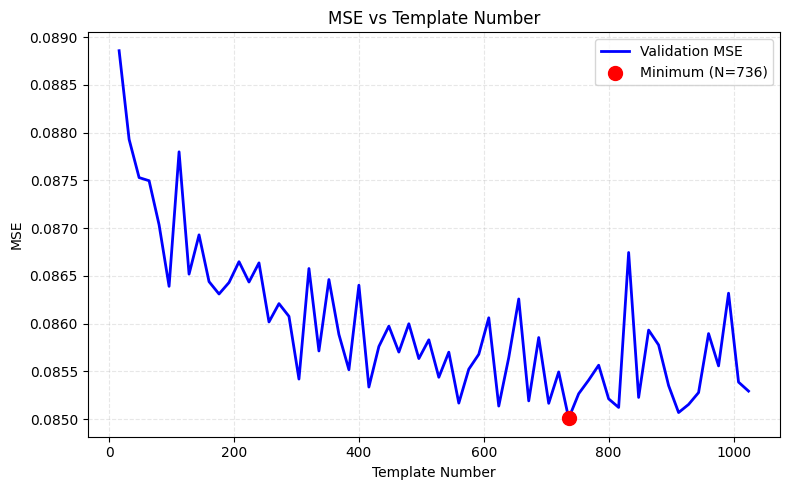

最小值点: N=736, MSE=0.085009


In [2]:
Template_NUM = [16, 32, 48, 64, 80, 96, 112, 128, 144, 160, 176, 192, 208, 224, 240, 256, 272, 288, 304, 320, 336, 352, 368, 384, 400, 416, 432, 448, 464, 480, 496, 512, 528, 544, 560, 576, 592, 608, 624, 640, 656, 672, 688, 704, 720, 736, 752, 768, 784, 800, 816, 832, 848, 864, 880, 896, 912, 928, 944, 960, 976, 992, 1008, 1024]

MSE_VAL = [0.088858858, 0.087930247, 0.087530142, 0.087497301, 0.087035483, 0.086391389, 0.087800007, 0.086519063, 0.086930299, 0.086440532, 0.08631113, 0.08643136, 0.086649356, 0.086436324, 0.086636772, 0.086018369, 0.08621024, 0.08607699, 0.085420137, 0.086577792, 0.085714374, 0.086462352, 0.085887097, 0.085517973, 0.08640302, 0.08533651, 0.08576161, 0.085974438, 0.085702559, 0.0859992, 0.085634666, 0.085831368, 0.085439036, 0.085701847, 0.085168388, 0.085523872, 0.085679527, 0.086061904, 0.085137289, 0.085645664, 0.086259063, 0.085191665, 0.085855087, 0.085166119, 0.085494943, 0.085008843, 0.085266845, 0.085409429, 0.085565226, 0.085213047, 0.085122986, 0.086745661, 0.085227789, 0.085933177, 0.085777055, 0.085352113, 0.085069623, 0.085154284, 0.085278889, 0.085896423, 0.085558016, 0.086319437, 0.085388236, 0.085293999]

min_N, min_MSE = plot_template_selection(Template_NUM, MSE_VAL)

print(f"最小值点: N={min_N}, MSE={min_MSE:.6f}")

Data of PEMS07

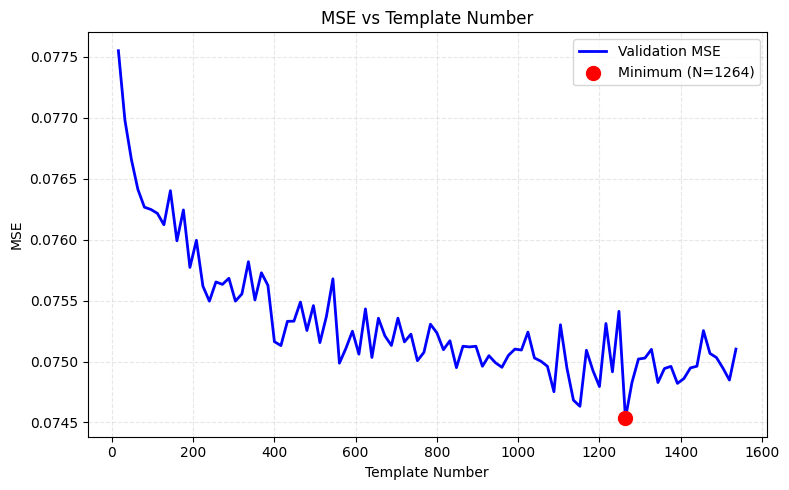

最小值点: N=1264, MSE=0.074534


In [3]:
Template_NUM = [16, 32, 48, 64, 80, 96, 112, 128, 144, 160, 176, 192, 208, 224, 240, 256, 272, 288, 304, 320, 336, 352, 368, 384, 400, 416, 432, 448, 464, 480, 496, 512, 528, 544, 560, 576, 592, 608, 624, 640, 656, 672, 688, 704, 720, 736, 752, 768, 784, 800, 816, 832, 848, 864, 880, 896, 912, 928, 944, 960, 976, 992, 1008, 1024, 1040, 1056, 1072, 1088, 1104, 1120, 1136, 1152, 1168, 1184, 1200, 1216, 1232, 1248, 1264, 1280, 1296, 1312, 1328, 1344, 1360, 1376, 1392, 1408, 1424, 1440, 1456, 1472, 1488, 1504, 1520, 1536]

MSE_VAL = [0.077550728, 0.076981755, 0.076657767, 0.076412431, 0.076266866, 0.076248093, 0.076215868, 0.076122324, 0.076402095, 0.075990692, 0.076244077, 0.07577241, 0.075995111, 0.075618744, 0.07549553, 0.075653279, 0.075633276, 0.075683203, 0.075496027, 0.075554876, 0.075819483, 0.075505806, 0.07572861, 0.075625133, 0.075163303, 0.0751312, 0.075330135, 0.075331403, 0.075488158, 0.075254716, 0.075459199, 0.075155412, 0.075370439, 0.075678897, 0.074986775, 0.075108689, 0.075248912, 0.075060545, 0.075432062, 0.075033799, 0.075355558, 0.07521039, 0.075131998, 0.075356066, 0.07516144, 0.075224717, 0.075006763, 0.075075598, 0.075306492, 0.075234946, 0.075097263, 0.075170797, 0.07495, 0.075125708, 0.075120125, 0.075125584, 0.074961362, 0.075048197, 0.074990445, 0.074952906, 0.075050725, 0.075102365, 0.075094491, 0.075241683, 0.075029523, 0.075002853, 0.07496101, 0.074752528, 0.075301936, 0.074946012, 0.074683125, 0.074632862, 0.075092667, 0.074925885, 0.074794887, 0.075312015, 0.074915811, 0.075412137, 0.07453406, 0.074827478, 0.075020703, 0.07502851, 0.075100079, 0.074827828, 0.074942656, 0.074960648, 0.074820923, 0.074860928, 0.07494785, 0.074961973, 0.075253979, 0.075066792, 0.075032928, 0.074945943, 0.074848123, 0.075102387]

min_N, min_MSE = plot_template_selection(Template_NUM, MSE_VAL)

print(f"最小值点: N={min_N}, MSE={min_MSE:.6f}")

Data of PEMS08

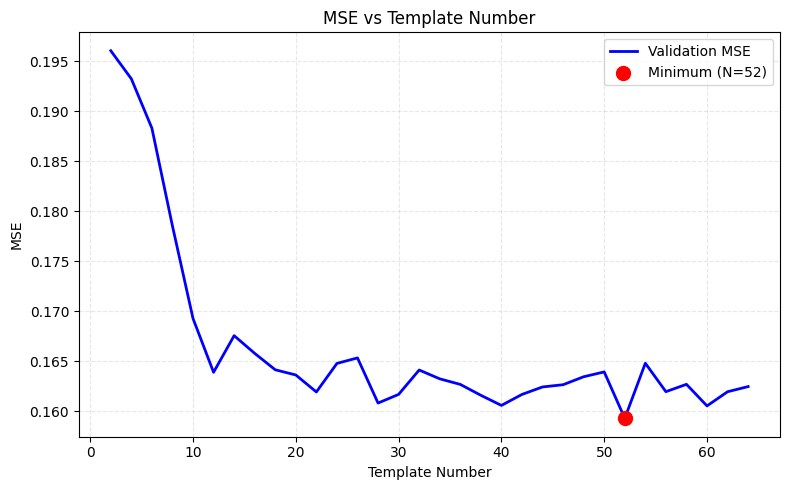

最小值点: N=52, MSE=0.159282


In [3]:
Template_NUM = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50, 52, 54, 56, 58, 60, 62, 64]

MSE_VAL = [0.196029063, 0.193221586, 0.188288167, 0.178509301, 0.169263972, 0.163884968, 0.167546947, 0.165775651, 0.164135434, 0.163616542, 0.161918059, 0.164772317, 0.165322876, 0.160809666, 0.161674725, 0.164112635, 0.1632325, 0.162673317, 0.161585685, 0.160574282, 0.161670955, 0.162419148, 0.162642296, 0.163439199, 0.163923282, 0.159281882, 0.164789513, 0.16194823, 0.162681388, 0.160526689, 0.161941983, 0.162456779]

min_N, min_MSE = plot_template_selection(Template_NUM, MSE_VAL)

print(f"最小值点: N={min_N}, MSE={min_MSE:.6f}")